## Import Required Libraries

In this section, all the necessary Python libraries are imported. These libraries are used for data manipulation, visualization, mathematical computations, and dataset preprocessing throughout the project.

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
# libraries imported 


##  Load the Dataset

The dataset is loaded into a Pandas DataFrame for further analysis. This marks the starting point of the machine learning workflow, allowing us to inspect and process the available data.

In [ ]:
data = pd.read_csv('../data/raw/student_performance_dataset.csv')
print("Done with data reading") 

Done with data reading


##  Initial Data Exploration

Before applying any preprocessing techniques, it is important to understand the structure of the dataset. This section examines the dataset's dimensions, data types, summary statistics, and missing values to identify potential issues that need to be addressed.

In [3]:
print(f"Number of (rows, cols): {data.shape}") 
print(f"Data-Type of each feature: {data.dtypes}") 
print(f"info => {data.info()}")
print(f"describe => {data.describe()}")
print(f"Head => {data.head()}")

Number of (rows, cols): (3000, 32)
Data-Type of each feature: student_id                       int64
age                              int64
gender                             str
city_type                          str
study_hours_per_day            float64
deep_work_sessions               int64
assignment_completion_rate       int64
attendance_percentage            int64
social_media_hours             float64
doomscrolling_before_sleep       int64
notification_distractions        int64
ai_tool_usage_hours            float64
gaming_hours                   float64
stress_level                     int64
motivation_level                 int64
focus_score                    float64
procrastination_index            int64
mental_state                       str
sleep_hours                    float64
caffeine_intake                  int64
physical_activity_hours        float64
internet_quality                 int64
family_support                   int64
financial_stress                 int64
le

In [4]:
print(data.isnull().sum())

student_id                      0
age                             0
gender                          0
city_type                       0
study_hours_per_day             0
deep_work_sessions              0
assignment_completion_rate      0
attendance_percentage           0
social_media_hours             60
doomscrolling_before_sleep      0
notification_distractions       0
ai_tool_usage_hours             0
gaming_hours                    0
stress_level                    0
motivation_level                0
focus_score                    60
procrastination_index           0
mental_state                    0
sleep_hours                    60
caffeine_intake                 0
physical_activity_hours         0
internet_quality                0
family_support                  0
financial_stress                0
learning_style                  0
career_goal                     0
productivity_after_midnight     0
revision_efficiency             0
burnout_risk                    0
consistency_sc

##  Exploratory Data Analysis (EDA)

This section explores the relationships, distributions, and patterns present in the dataset using various visualizations. Understanding the data through graphical analysis helps identify trends and supports informed feature selection.

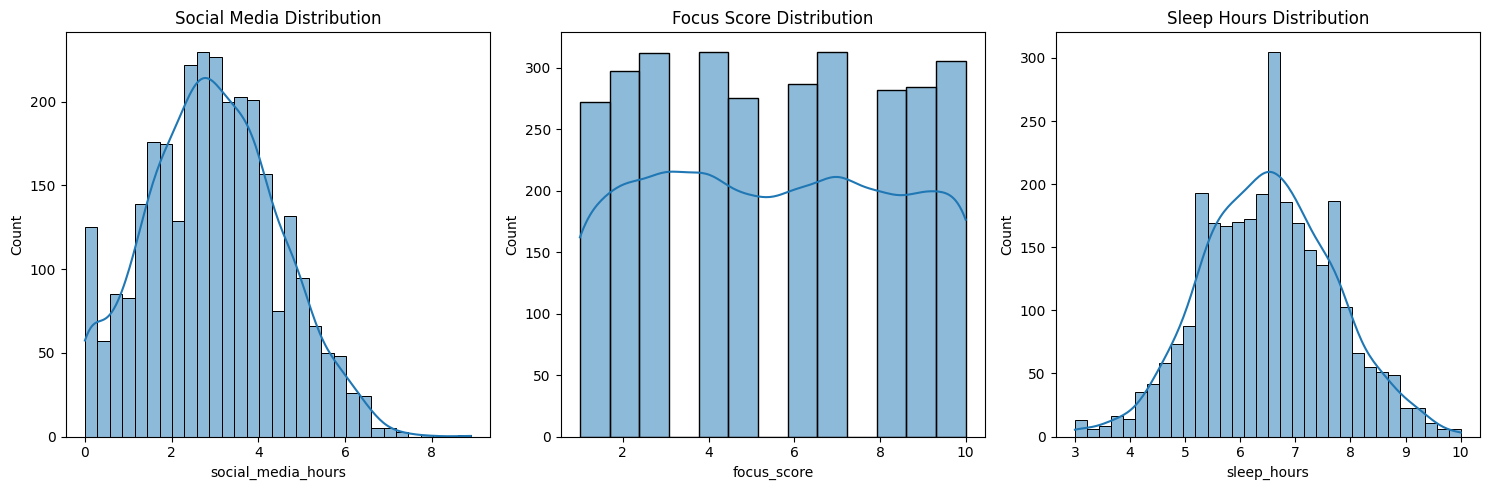

In [5]:


# features
social_media = data['social_media_hours']
focus_score = data['focus_score']
sleep_hours = data['sleep_hours']

missing_columns = [social_media, focus_score, sleep_hours]
missing_columns_names = ["Social Media", "Focus Score", "Sleep Hours"]
plt.figure(figsize=(15,5))

# Social Media
plt.subplot(1,3,1)
sns.histplot(social_media, kde=True)
plt.title("Social Media Distribution")

# Focus Score
plt.subplot(1,3,2)
sns.histplot(focus_score, kde=True)
plt.title("Focus Score Distribution")

# Sleep Hours
plt.subplot(1,3,3)
sns.histplot(sleep_hours, kde=True)
plt.title("Sleep Hours Distribution")

plt.tight_layout()
plt.show()


In [6]:
print(f"Social Media Hours skewness: {round(social_media.skew(),2)}")
print(f"Focus Score skewness: {round(focus_score.skew(),2)}")
print(f"Sleep Hours skewness: {round(sleep_hours.skew(),2)}")

# agr hmaaray paas skewness ki range -0.5 se 0.5 ke btw ha tw mean imputation use kro 
# agr iss range mein ksi bhi side se nhin ha tw median imputation use kro 

Social Media Hours skewness: 0.14
Focus Score skewness: 0.02
Sleep Hours skewness: 0.03


Text(0.5, 1.0, 'Sleep Hours Boxplot')

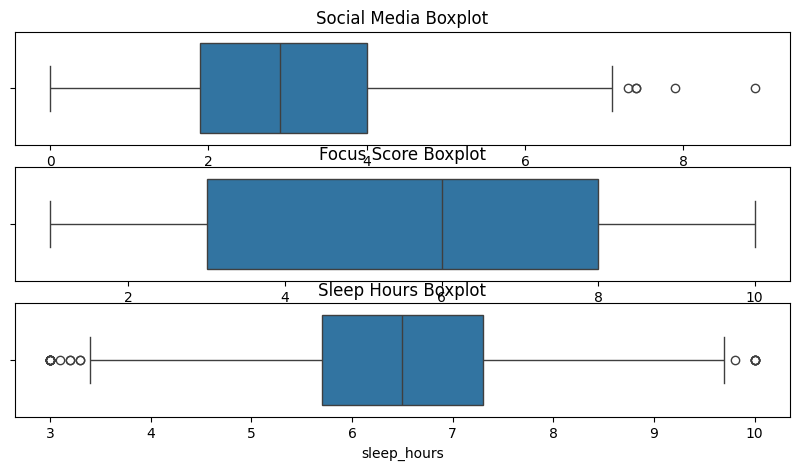

In [7]:
# plotting a boxplot to check ke outliers kitny hein agr mere paas outliers aty hein tw mein median 
# imputation ko follow kron ga 


plt.figure(figsize = (10,5))

plt.subplot(3,1,1)
sns.boxplot(x = social_media)
plt.title("Social Media Boxplot")


plt.subplot(3,1,2)
sns.boxplot(x = focus_score)
plt.title("Focus Score Boxplot")


plt.subplot(3,1,3)
sns.boxplot(x = sleep_hours)
plt.title("Sleep Hours Boxplot")

In [8]:
# filling those 3 features with median 
data['social_media_hours'] = data['social_media_hours'].fillna(data['social_media_hours'].median())
data['focus_score'] = data['focus_score'].fillna(data['focus_score'].median())
data['sleep_hours'] = data['sleep_hours'].fillna(data['sleep_hours'].median())

In [ ]:
data.isnull().sum()

data.to_csv("../data/processed_data/processed_data.csv", index = False) 

##  Feature Correlation Analysis

Correlation analysis is performed to measure the strength of relationships between variables. This helps identify the most influential features that contribute to predicting student performance.

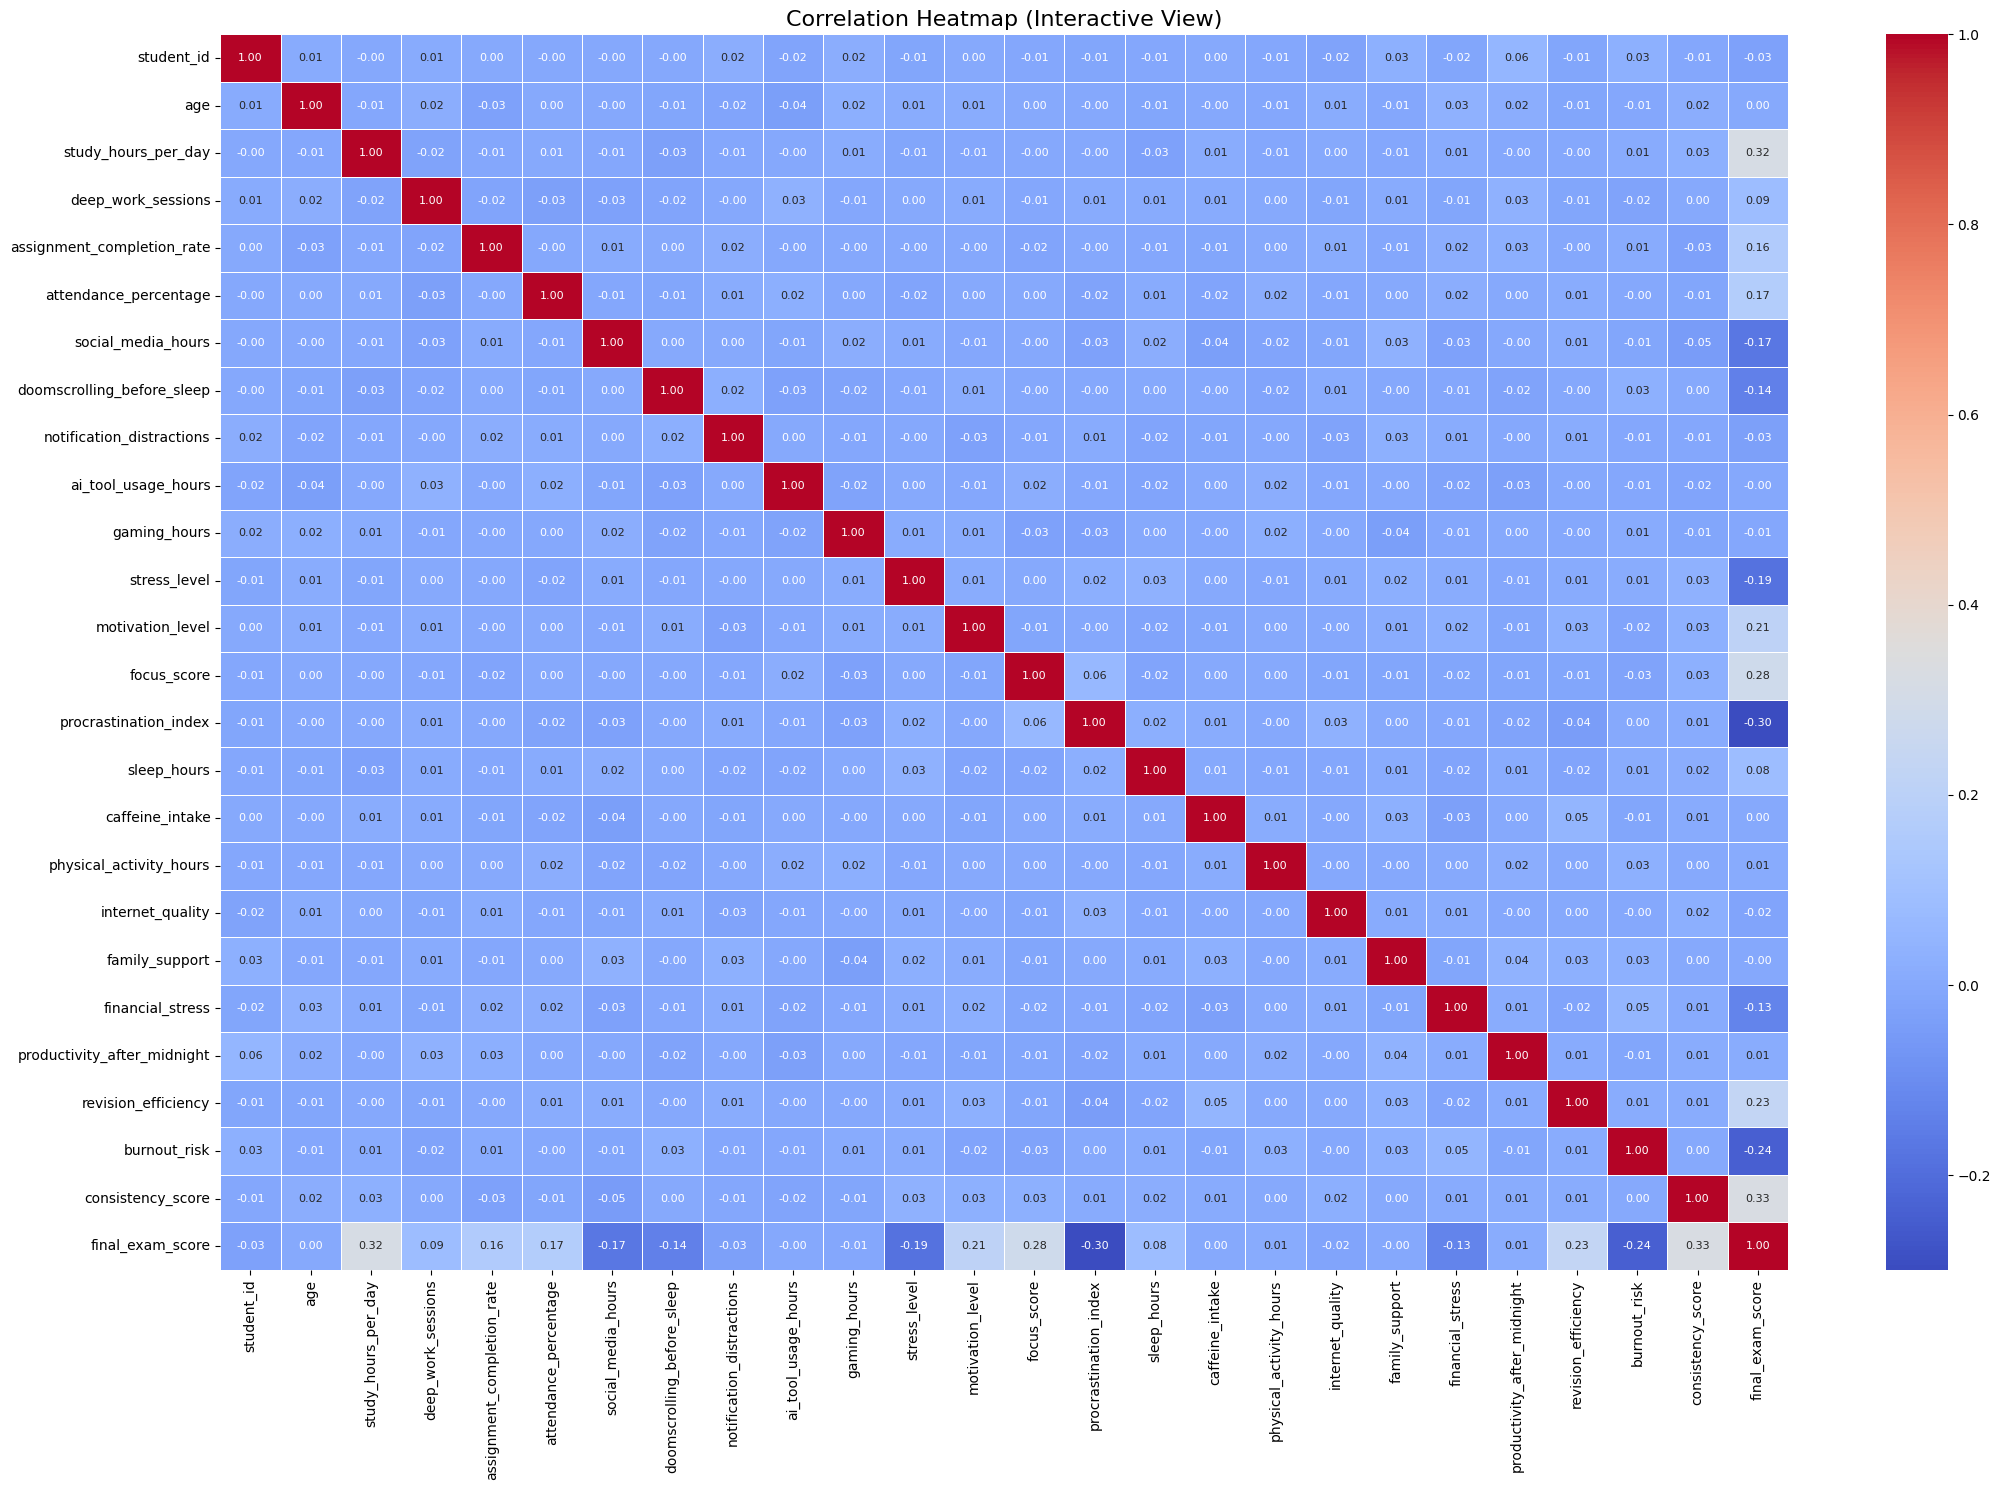

In [10]:
# 1. Is line se plot ek alag interactive pop-up window mein khulega

# yahan hum saaray data set ka correlation plot kr rhy hein 

plt.figure(figsize=(22, 15)) 

corr_matrix = data.corr(numeric_only=True)

sns.heatmap(
    corr_matrix, 
    annot=True, 
    fmt='.2f',          # <--- Sirf 2 decimal places dikhayega
    cmap='coolwarm', 
    linewidths=0.5,     # <--- Har box ke darmiyan halki line line
    annot_kws={"size": 8} # <--- Font size chhota taaki text fit aaye
)

plt.title("Correlation Heatmap (Interactive View)", fontsize=16)
plt.tight_layout() # <--- Isse labels cut-off nahi hote
plt.show()

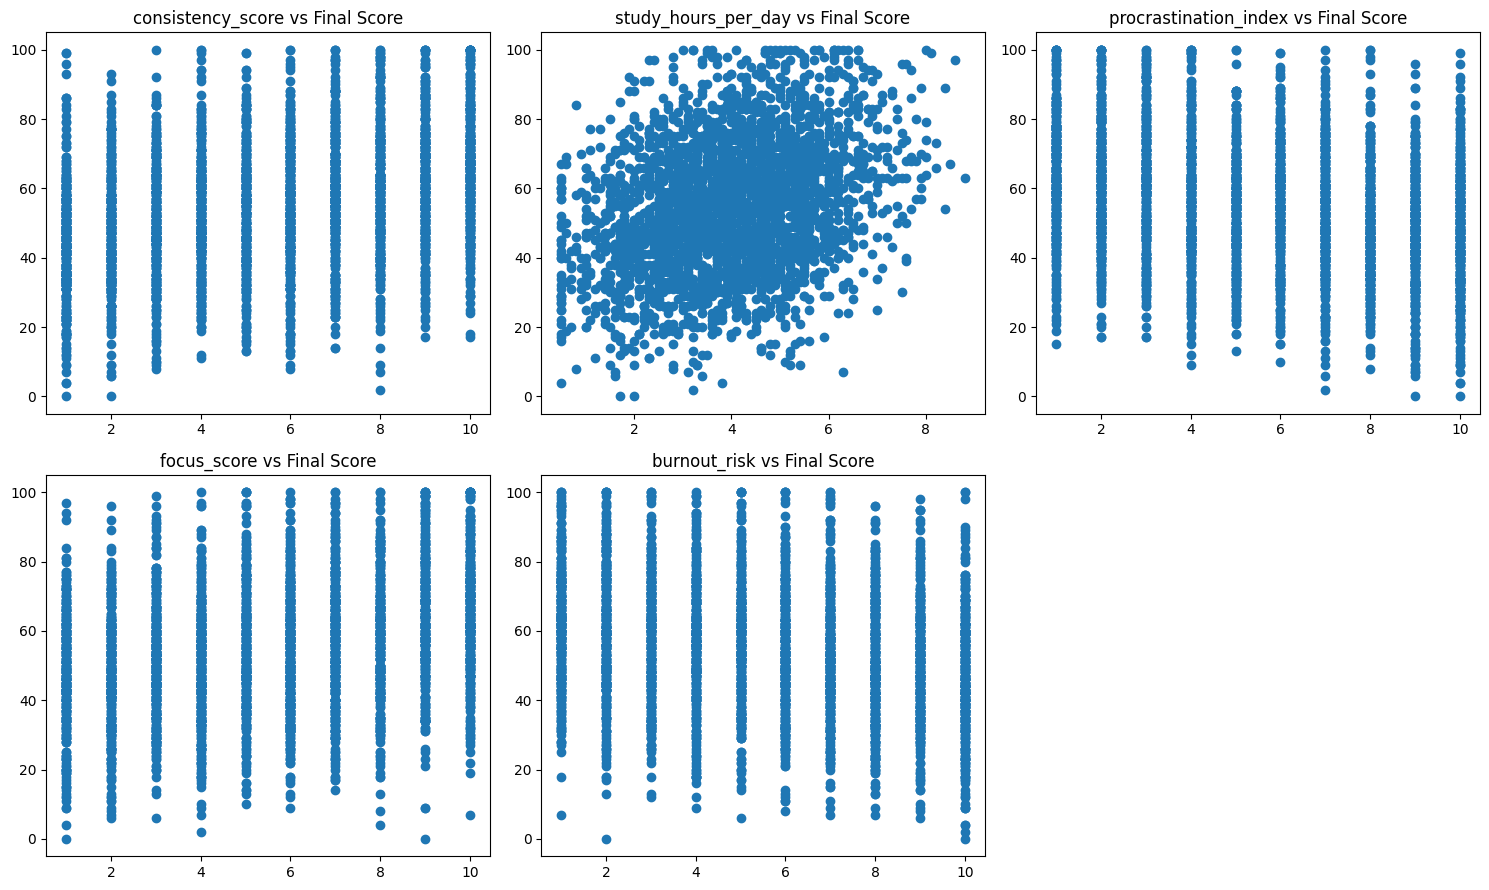

In [11]:
strong_five_features = data.corr(numeric_only=True)['final_exam_score'].abs().nlargest(6).index.tolist()

strong_five_features = strong_five_features[1:]

plt.figure(figsize = (15,9))

for i, col in enumerate(strong_five_features): 
    plt.subplot(2,3,i+1)
    plt.scatter(data[col], data['final_exam_score'])
    plt.title(f"{col} vs Final Score")

plt.tight_layout()
plt.show()

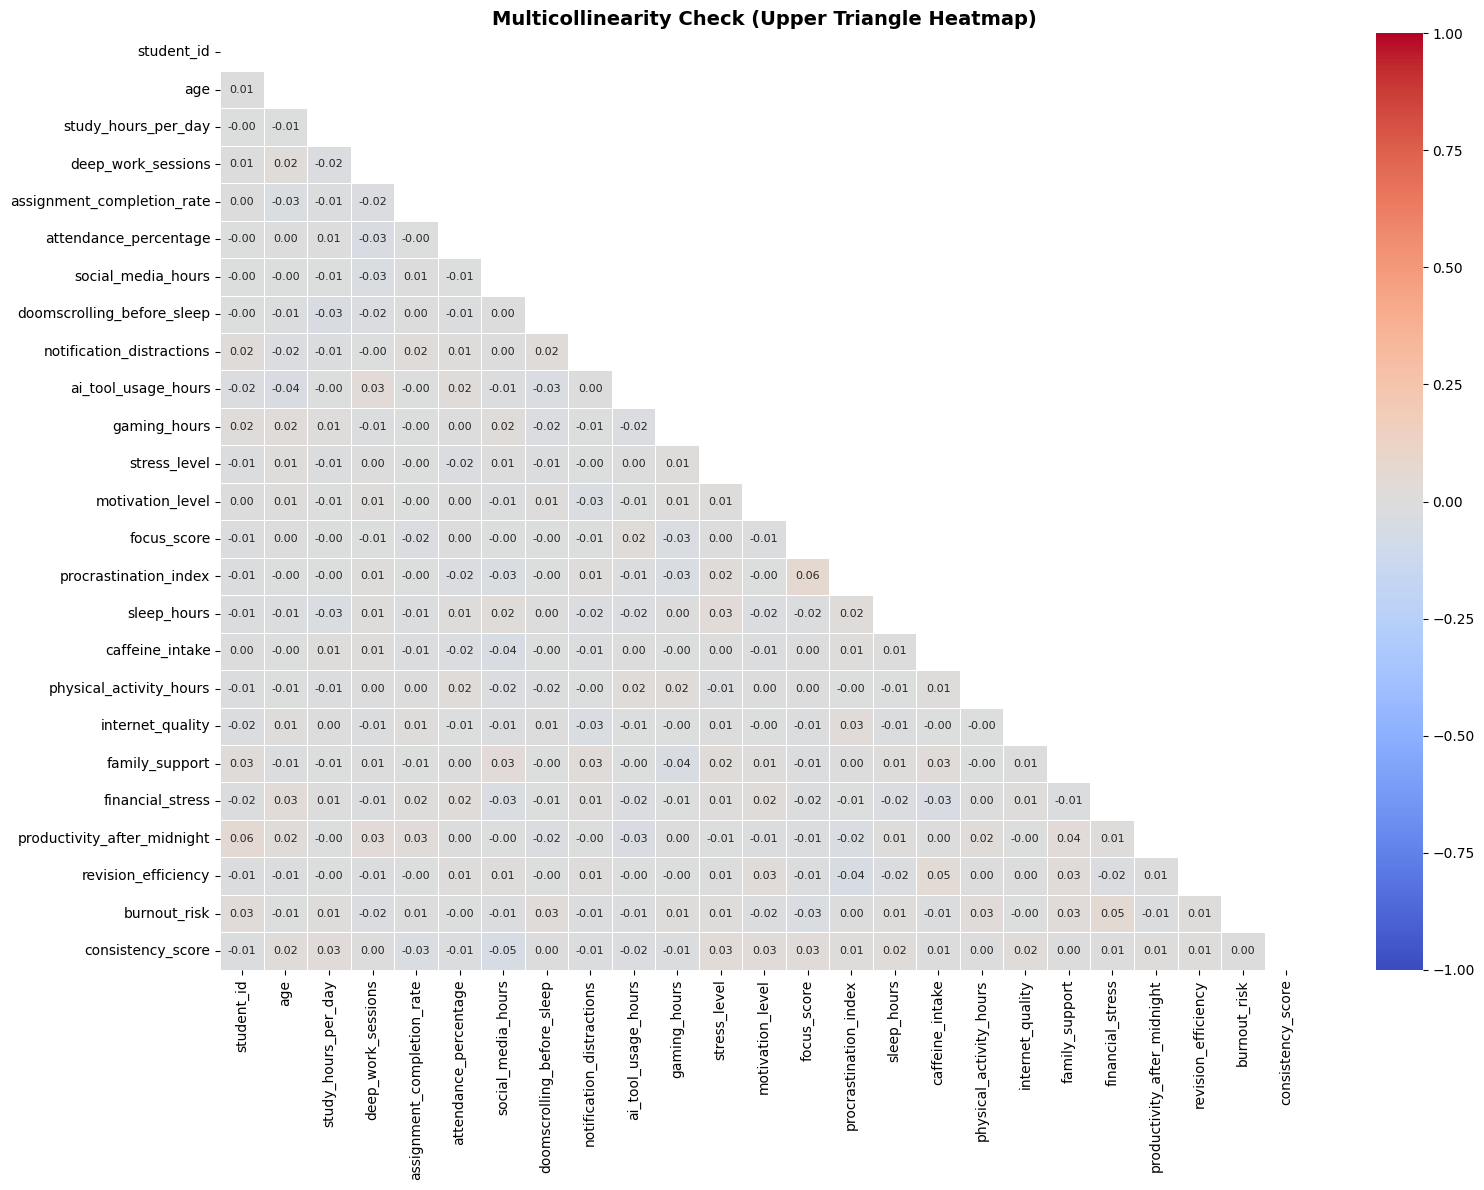

In [12]:


# 1. Correlation matrix nikalye (excluding target feature taaki sirf features aapas mein check hon)
features_corr = data.drop(columns=['final_exam_score']).corr(numeric_only=True)

# 2. Upper triangle ka mask banayein taaki mirror values hide ho jayein
mask = np.triu(np.ones_like(features_corr, dtype=bool))

# 3. Plotting size aur style
plt.figure(figsize=(16, 12))
sns.heatmap(
    features_corr, 
    mask=mask,               # <--- Duplicate values hide ho jayengi
    annot=True, 
    fmt='.2f', 
    cmap='coolwarm', 
    vmin=-1, vmax=1,         # <--- Scale limit set karein
    linewidths=0.5,
    annot_kws={"size": 8}
)
plt.title("Multicollinearity Check (Upper Triangle Heatmap)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [13]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Sirf numerical independent features select karein (missing values fill honi chahiye)
X_features = data.drop(columns=['final_exam_score']).select_dtypes(include=[np.number])

# VIF calculate karein
vif_data = pd.DataFrame()
vif_data["feature"] = X_features.columns
vif_data["VIF"] = [variance_inflation_factor(X_features.values, i) for i in range(len(X_features.columns))]

# Sort karke check karein
print(vif_data.sort_values(by="VIF", ascending=False))

                        feature        VIF
1                           age  40.879715
15                  sleep_hours  26.507653
5         attendance_percentage  24.051801
4    assignment_completion_rate  15.404426
2           study_hours_per_day   7.733008
6            social_media_hours   4.812870
23                 burnout_risk   4.773059
21  productivity_after_midnight   4.739248
20             financial_stress   4.738796
13                  focus_score   4.729276
12             motivation_level   4.693583
24            consistency_score   4.689865
14        procrastination_index   4.685492
19               family_support   4.654507
11                 stress_level   4.638055
18             internet_quality   4.588087
22          revision_efficiency   4.500470
8     notification_distractions   4.435586
0                    student_id   3.969532
9           ai_tool_usage_hours   3.711168
16              caffeine_intake   3.348468
3            deep_work_sessions   3.312997
10         

In [14]:
# ab yahan upr tkk mein ne Multicollinearity aur VIF apply kr rha ha aur mere paas kuchh suspicious features nikly hein tw mein ne 
# unn ko check krna ha 

#1. sbb se pehle student_id nikaalo
if "student_id" in data.columns: 
    data = data.drop(columns = ["student_id"])



In [15]:
data[["age", 'sleep_hours', "attendance_percentage", "assignment_completion_rate"]].corr()

,age,sleep_hours,attendance_percentage,assignment_completion_rate
age,1.000000,-0.013682,0.001789,-0.026400
sleep_hours,-0.013682,1.000000,0.008528,-0.007975
attendance_percentage,0.001789,0.008528,1.000000,-0.004436
assignment_completion_rate,-0.026400,-0.007975,-0.004436,1.000000


In [16]:
# identifying the object type columns ( such as the ones with string data type )

cat_data = data.select_dtypes('object')
cat_data


C:\Users\pc\AppData\Local\Temp\ipykernel_7064\3988826605.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_data = data.select_dtypes('object')


,gender,city_type,mental_state,learning_style,career_goal,performance_category
0,Female,Semi-Urban,Balanced,Audio,Engineering,Low
1,Female,Semi-Urban,Burnout,Practical,Business,Medium
2,Female,Urban,Burnout,Visual,Engineering,Low
3,Male,Semi-Urban,Burnout,Reading,Medical,Medium
4,Female,Urban,Focused,Visual,Medical,High
...,...,...,...,...,...,...
2995,Female,Rural,Balanced,Practical,Arts,Low
2996,Female,Urban,Burnout,Visual,Medical,High
2997,Female,Rural,Balanced,Practical,Engineering,Medium
2998,Male,Urban,Focused,Practical,Medical,High


In [17]:
#understanding the unique values and the categories 

for i in cat_data.columns: 
    print(f"{i} => {cat_data[i].unique()}") 
    print()

count = cat_data.value_counts()
print(count)

gender => <StringArray>
['Female', 'Male']
Length: 2, dtype: str

city_type => <StringArray>
['Semi-Urban', 'Urban', 'Rural']
Length: 3, dtype: str

mental_state => <StringArray>
['Balanced', 'Burnout', 'Focused', 'Distracted']
Length: 4, dtype: str

learning_style => <StringArray>
['Audio', 'Practical', 'Visual', 'Reading']
Length: 4, dtype: str

career_goal => <StringArray>
['Engineering', 'Business', 'Medical', 'Arts', 'Research']
Length: 5, dtype: str

performance_category => <StringArray>
['Low', 'Medium', 'High']
Length: 3, dtype: str

gender  city_type   mental_state  learning_style  career_goal  performance_category
Male    Urban       Burnout       Audio           Medical      Low                     11
        Semi-Urban  Burnout       Audio           Arts         Low                     11
Female  Semi-Urban  Burnout       Practical       Arts         Low                      9
Male    Urban       Burnout       Reading         Arts         Low                      9
Female  

In [18]:
# removing the performance_category, since it would cause data leakage ke uss se humein pehle hi pta chl skta ha score range ka etc 
# and it is being derived from the score so no need to keep this in the data we are going to use for training/testing 

if "performance_category" in data.columns.tolist(): 
    data = data.drop (columns = ["performance_category"])

data.head()


,age,gender,city_type,study_hours_per_day,deep_work_sessions,assignment_completion_rate,attendance_percentage,social_media_hours,doomscrolling_before_sleep,notification_distractions,...,internet_quality,family_support,financial_stress,learning_style,career_goal,productivity_after_midnight,revision_efficiency,burnout_risk,consistency_score,final_exam_score
0,21,Female,Semi-Urban,3.2,7,100,70,3.8,0,107,...,1,10,6,Audio,Engineering,9,1,10,3,32
1,19,Female,Semi-Urban,3.9,2,46,70,2.6,1,93,...,4,2,6,Practical,Business,6,10,4,6,59
2,16,Female,Urban,4.3,7,54,57,4.3,1,82,...,9,1,9,Visual,Engineering,7,9,8,1,34
3,19,Male,Semi-Urban,5.3,1,78,90,1.7,0,27,...,1,5,10,Reading,Medical,7,7,9,10,60
4,17,Female,Urban,4.1,3,100,81,2.6,0,8,...,9,5,6,Visual,Medical,4,10,7,9,77


In [19]:
data = pd.get_dummies(data, drop_first=True) 
data.head()

bool_features = data.select_dtypes(include ='bool').columns.tolist()
data[bool_features] = data[bool_features].astype('int8')
data.head()

,age,study_hours_per_day,deep_work_sessions,assignment_completion_rate,attendance_percentage,social_media_hours,doomscrolling_before_sleep,notification_distractions,ai_tool_usage_hours,gaming_hours,...,mental_state_Burnout,mental_state_Distracted,mental_state_Focused,learning_style_Practical,learning_style_Reading,learning_style_Visual,career_goal_Business,career_goal_Engineering,career_goal_Medical,career_goal_Research
0,21,3.2,7,100,70,3.8,0,107,0.6,1.8,...,0,0,0,0,0,0,0,1,0,0
1,19,3.9,2,46,70,2.6,1,93,1.5,1.1,...,1,0,0,1,0,0,1,0,0,0
2,16,4.3,7,54,57,4.3,1,82,0.5,0.0,...,1,0,0,0,0,1,0,1,0,0
3,19,5.3,1,78,90,1.7,0,27,1.4,3.8,...,1,0,0,0,1,0,0,0,1,0
4,17,4.1,3,100,81,2.6,0,8,1.3,2.5,...,0,0,1,0,0,1,0,0,1,0


In [20]:
target = "final_exam_score"
X = data.drop(columns = [target])
y = data[target]



##  Split the Dataset

The dataset is divided into training and testing sets. The training data is used to learn the model parameters, while the testing data is reserved for evaluating the model's performance on unseen data.

In [21]:
from sklearn.model_selection import train_test_split 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)


##  Feature Scaling

Machine learning algorithms often perform better when numerical features are on a similar scale. This section standardizes the selected features to improve the efficiency and stability of the learning process.

In [22]:
from sklearn.preprocessing import StandardScaler 

scaler = StandardScaler() 

X_trained_scaled = scaler.fit_transform(X_train) 
X_test_scaled = scaler.transform(X_test)

# mean = X.mean()
# std = X.std() 
# X_train_scaled = (X_train - mean) / std 
# X_test_scaled = (X_test - mean) / std 

In [138]:
X_trained_scaled.std()


np.float64(1.0)

In [139]:
X_trained_scaled = np.c_[np.ones(X_trained_scaled.shape[0]), X_trained_scaled]
X_test_scaled = np.c_[np.ones(X_test_scaled.shape[0]), X_test_scaled]

# np.c_ se column wise concatenation hoti ha 

theta = np.zeros(X_trained_scaled.shape[1])
# initially mein ne theto ko zero rkha ha ke abhi weights assign nhin hoye aur random achhi approach nhin



##  Manual Implementation of Linear Regression

Instead of using a pre-built machine learning model, Linear Regression is implemented manually using mathematical equations. This approach provides a deeper understanding of how regression algorithms calculate predictions and optimize model parameters.

In [140]:
def hypothesis_function(X, theta): 
    return np.dot(X,theta)


# the below is just for testing 


#predictions = hypothesis_function(X_trained_scaled, theta)
#print(predictions[:5])

In [141]:
#cost function = 1 / m * sum of all (actual - predition)^2 
# would use theta and X_trained_scaled for prediction and y_train for actual 

def error_cal(pred, y): 
    return (pred - y) 

def cost_function(X, y, theta): 
    m = len(y)

    predictions = hypothesis_function(X, theta)
    difference = error_cal(predictions, y)
    square_of_difference = difference ** 2 
    cost = 1 /(2*m) * (np.sum(square_of_difference))

    return cost


# the below code is just for checking the function 
comparison = pd.DataFrame() 
comparison["Actual"] = y_train[:5]
comparison["Prediction"] = hypothesis_function(X_trained_scaled, theta)[:5]
comparison["Cost"] = cost_function(X_trained_scaled, y_train, theta)
comparison["Error"] = error_cal(hypothesis_function(X_trained_scaled, theta), y_train)[:5]
comparison.head()

,Actual,Prediction,Cost,Error
642,67,0.0,1675.895,-67.0
700,95,0.0,1675.895,-95.0
226,44,0.0,1675.895,-44.0
1697,77,0.0,1675.895,-77.0
1010,43,0.0,1675.895,-43.0


Iteration # 0
Cost: 1643.12 
Initial Theta Values: [ 5.47625000e-01 -2.12061164e-04  6.05720604e-02  1.61245193e-02
  2.75923780e-02]


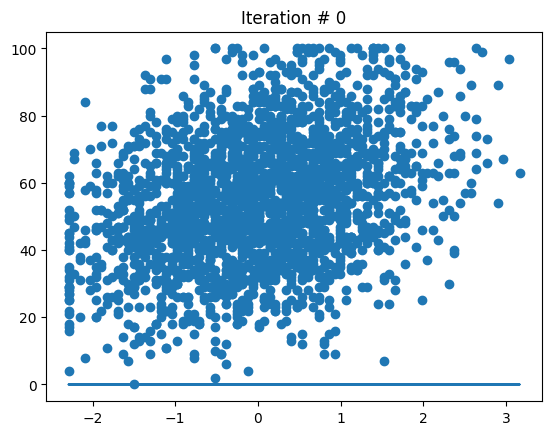

--------------------------------------------------
Iteration # 50
Cost: 621.58 
Initial Theta Values: [21.9621717  -0.0301431   2.42234573  0.68724756  1.16472523]


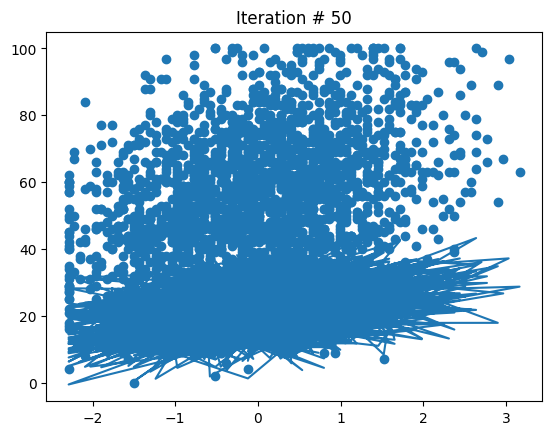

--------------------------------------------------
Iteration # 100
Cost: 248.68 
Initial Theta Values: [34.91810237 -0.07353674  3.844537    1.14307464  1.92788714]


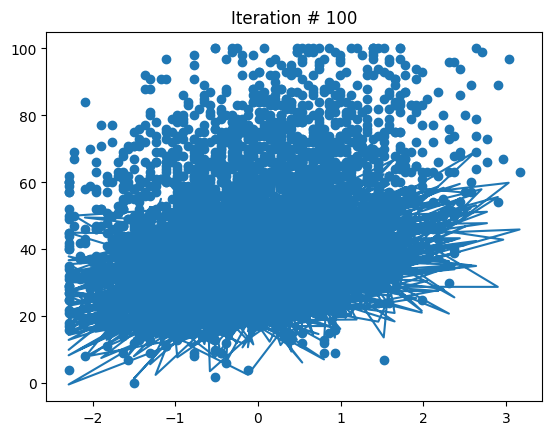

--------------------------------------------------
Iteration # 150
Cost: 112.33 
Initial Theta Values: [42.75651904 -0.1128283   4.70305658  1.44728185  2.43547019]


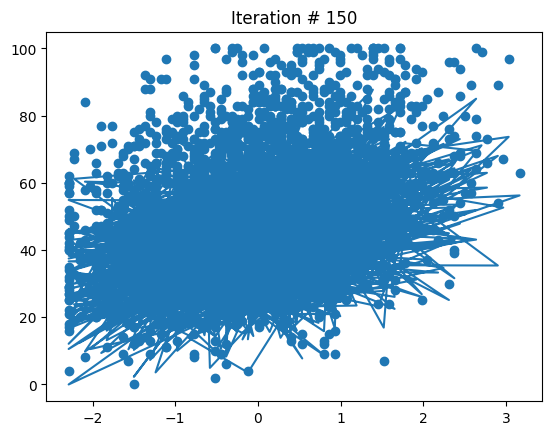

--------------------------------------------------
Iteration # 200
Cost: 62.4 
Initial Theta Values: [47.49880868 -0.1432647   5.22273861  1.6480847   2.77084105]


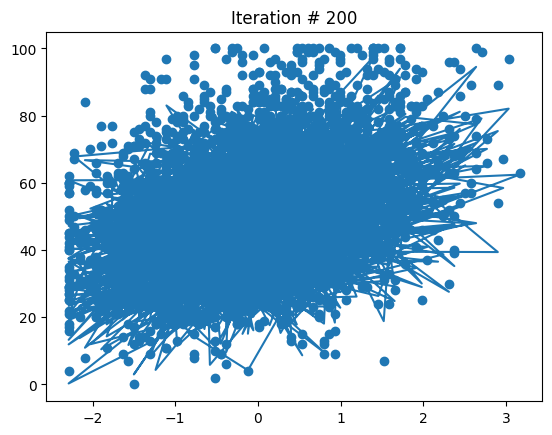

--------------------------------------------------
Iteration # 250
Cost: 44.09 
Initial Theta Values: [50.36792268 -0.16502153  5.53831147  1.77977189  2.99140648]


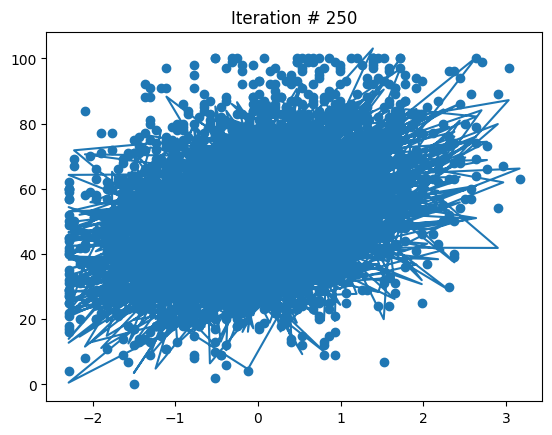

--------------------------------------------------
Iteration # 300
Cost: 37.35 
Initial Theta Values: [52.10375406 -0.17979923  5.7306601   1.86585442  3.13605514]


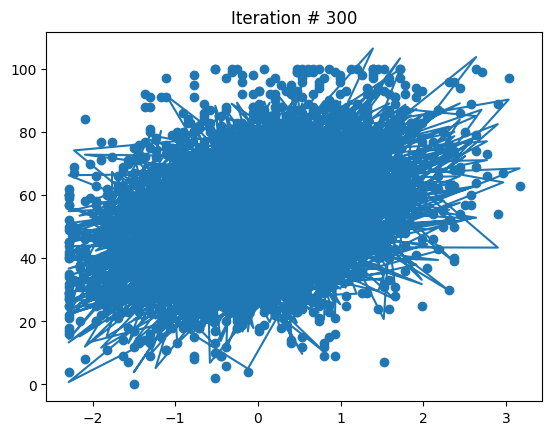

--------------------------------------------------
Iteration # 350
Cost: 34.86 
Initial Theta Values: [53.15394257 -0.18946258  5.84843587  1.92209043  3.23080791]


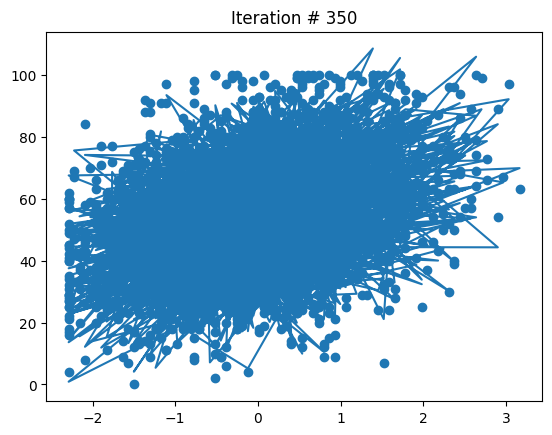

--------------------------------------------------
Iteration # 400
Cost: 33.94 
Initial Theta Values: [53.789313   -0.19557863  5.92095873  1.95888761  3.29291163]


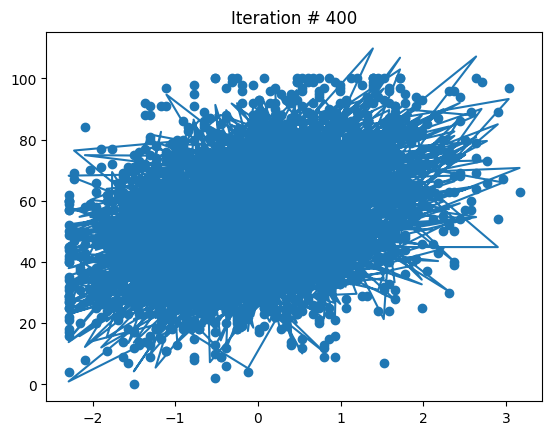

--------------------------------------------------
Iteration # 450
Cost: 33.59 
Initial Theta Values: [54.17371596 -0.19932529  5.96593434  1.98305455  3.33371448]


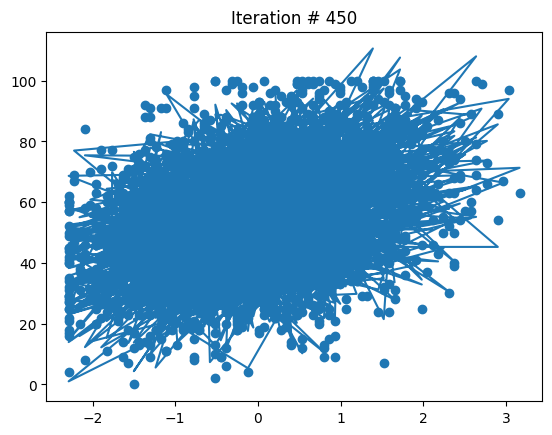

--------------------------------------------------


In [146]:

theta = np.zeros(X_trained_scaled.shape[1])
def gradient_descent(X, y, theta, lr = 0.01, epochs = 500): 

    X_single = X[:,2]
    m = len(y) 
    costs = [] 
    check_point = epochs // 10 

    for i in range(epochs): 

        pred = hypothesis_function(X,theta)
        
        error = error_cal(pred, y)
        
        derivative = 1/m * np.dot(X.T, error)
        
        theta = theta - lr * derivative 
        
        cost = cost_function(X,y,theta) 

        costs.append(cost)

        if ( i % check_point == 0 ): 
            print(f"Iteration # {i}") 
            print(f"Cost: {round(cost,2)} ")
            print(f"Initial Theta Values: {theta[:5]}")

            plt.scatter(X_single,y) # actual values jo hein wo dots se show ho rhi hein 
            plt.plot(X_single, pred) # predicted values ko line se show kraa dia 

            plt.title(f"Iteration # {i}")
            plt.show()


            print("-" * 50 )
    
    return theta, costs 

theta, cost_history = gradient_descent(X_trained_scaled, y_train, theta)


In [147]:
testing_predictions = hypothesis_function(X_test_scaled, theta)

comparison = pd.DataFrame() 
comparison["Actual"] = y_test[:5]
comparison["Prediction"] = hypothesis_function(X_test_scaled, theta)[:5]
#comparison["Cost"] = cost_function(X_test_scaled, y_test, theta)
comparison["Error"] = error_cal(hypothesis_function(X_test_scaled, theta), y_test)[:5]
comparison.head()

,Actual,Prediction,Error
1801,44,45.445557,1.445557
1190,72,57.614930,-14.385070
1817,55,55.794917,0.794917
251,51,45.436802,-5.563198
2505,44,41.642639,-2.357361


In [152]:
# calculate mae to check model kitna off ha aap ka 
error = error_cal(hypothesis_function(X_test_scaled, theta), y_test)

mean_abs_error = np.mean(np.abs(error))
mean_sqr_error = np.mean(error**2)
root_mse = mean_sqr_error ** 0.5 

def r2_calculation(y, pred): 

    ss_tot = np.sum(( y - np.mean(y)) **2 )
    ss_res = np.sum((y - pred)**2)

    r2_score = 1 - ss_res/ss_tot

    return r2_score

print(f"Mean Abs Error(MAE): {round(mean_abs_error,3)}")
print(f"Mean Square Error (MSE): {round(mean_sqr_error,3)}")
print(f"Root Mean Square Error(RMSE): {round(root_mse,3)}")
print(f"R2 Score: {(r2_calculation(y_test, hypothesis_function(X_test_scaled, theta)))}")



Mean Abs Error(MAE): 6.504
Mean Square Error (MSE): 64.959
Root Mean Square Error(RMSE): 8.06
R2 Score: 0.8059678413136943


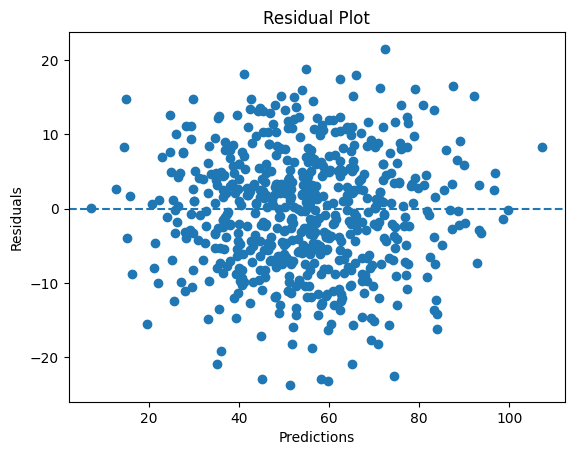

In [ ]:
plt.scatter(testing_predictions, error)
plt.axhline( y = 0 , linestyle = '--' )
plt.xlabel("Predictions")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

In [157]:
train_predictions = hypothesis_function(X_trained_scaled, theta)
test_predictions = hypothesis_function(X_test_scaled, theta)

train_mse = np.mean((train_predictions - y_train)**2)
test_mse = np.mean((test_predictions - y_test)**2)

print(round(train_mse,2))
print(round(test_mse,2))

66.92
64.96


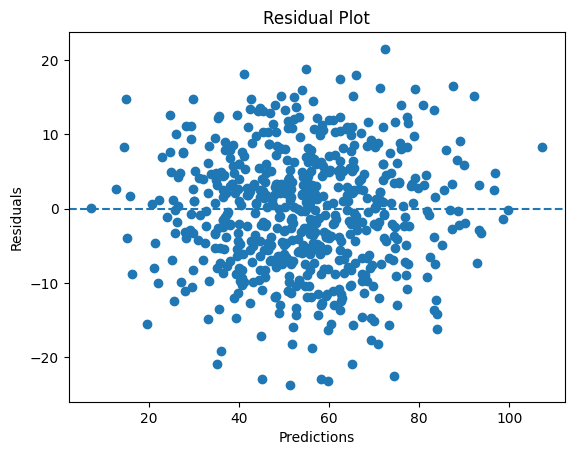

In [158]:
errors = test_predictions - y_test

plt.scatter(test_predictions, errors)

plt.axhline(y=0, linestyle='--')

plt.xlabel("Predictions")

plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.show()

In [ ]:
mape = np.mean(
    np.abs((y_test - test_predictions) / y_test)
) * 100

accuracy = 100 - mape

print("MAPE:", mape)

print("Approx Accuracy:", accuracy)

# this one is optional though 

MAPE: inf
Approx Accuracy: -inf
